<a href="https://colab.research.google.com/github/xc308/Understanding-Transformer-Attention-Weights/blob/main/Visualisation_Transformer_Attention_Weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Visualisation Transformer Attention Weights**

- Understand how attention weights indicate which tokens contribute most to predicting the next token

- Understand how attention can cross sentence boundaries and capture context from earlier sentences.


- Attention allows the model to build contextual embeddings that combine information from all tokens in the prompt

- After training, this mechanism learns how much each token in the prompt should be attended to when predict the next token


In [ ]:
!pip install orbax-checkpoint==0.11.21
!pip install "git+https://github.com/google-deepmind/ai-foundations.git@main"

from ai_foundations import generation # For loading and prompting Gemma.
from ai_foundations import visualizations # For attention weight visualization.

  Cloning https://github.com/google-deepmind/ai-foundations.git (to revision main) to /tmp/pip-req-build-j37gyf7k
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/ai-foundations.git /tmp/pip-req-build-j37gyf7k
  Resolved https://github.com/google-deepmind/ai-foundations.git to commit 524d6114bbce631dafc00ba3496607a0bc60c804
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Initialize caches for prompts.
previous_prompt = None
previous_prompt2 = None

# Load special version of the Gemma-1B model that provides access to attention
# weights.
print("Loading Gemma-1B...")
model = generation.load_gemma("Gemma-1B-AttentionWeight")
print("Loaded Gemma-1B.")

Loading Gemma-1B...
Loaded Gemma-1B.


Generated text: Jide was hungry so she went looking for food


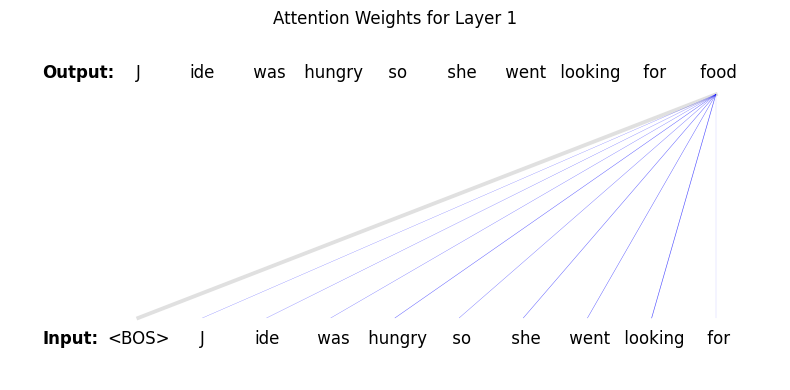

In [ ]:
# @title Visualize attention weights
layer = 1 # @param {type:"slider", min: 0, max: 25}

prompt = "Jide was hungry so she went looking for"  # @param {type: "string"}

show_all_weights = False


if prompt != previous_prompt:
    (output_text, next_token_logits, tokenizer, attention_weights, _, _) = (
        generation.prompt_attention_transformer_model(
            prompt, model, sampling_mode="greedy"
        )
    )
    tokens = [tokenizer.tokens[t] for t in tokenizer.encode(output_text)]
    previous_prompt = prompt

print(f"Generated text: {output_text}")

visualizations.visualize_attention(
    tokens,
    attention_weights[f"layer_{layer}"],
    layer,
    min_line_thickness=0,
    max_line_thickness=5,
    show_all_weights=show_all_weights
)